In [1]:
# %% Install Libraries
!pip install nltk textstat xgboost lightgbm emoji scikit-learn seaborn tqdm matplotlib --quiet

# %% Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.sparse import hstack
from tqdm import tqdm
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
import emoji
import time
# Download VADER lexicon
nltk.download('vader_lexicon')

# Config
np.random.seed(42)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mercy\AppData\Roaming\nltk_data...


In [2]:
# %% Load Dataset
DATASET_PATH = "../../../Dataset/Mohamed_Dataset/snapshots/youtube_dataset_snapshot_20251028_144628.csv"
data = pd.read_csv(DATASET_PATH, low_memory=False)

# Keep only relevant columns
data = data[['title', 'viewCount']].copy()
data['title'] = data['title'].astype(str)

# Remove titles with hashtags or empty titles
data = data[~data['title'].str.contains('#', regex=False, na=False)]
data = data[data['title'].str.strip() != '']

# Target: log transform of views
data['log_views'] = np.log1p(data['viewCount'])


In [3]:
# %% Feature Engineering
# Sentiment
sid = SentimentIntensityAnalyzer()
data['sentiment'] = data['title'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Readability
data['readability'] = data['title'].apply(textstat.flesch_reading_ease)

# Text-based numeric features
data['title_length'] = data['title'].apply(len)
data['word_count'] = data['title'].apply(lambda x: len(x.split()))
data['uppercase_word_count'] = data['title'].apply(lambda x: len([w for w in x.split() if w.isupper()]))
data['emoji_count'] = data['title'].apply(emoji.emoji_count)
data['punctuation_count'] = data['title'].apply(lambda x: len([c for c in x if c in '.,?!:;']))
data['has_question_mark'] = data['title'].apply(lambda x: '?' in x).astype(int)
data['has_exclamation_mark'] = data['title'].apply(lambda x: '!' in x).astype(int)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = vectorizer.fit_transform(data['title'])

# Numeric features
numeric_features = ['sentiment','readability','title_length','word_count','uppercase_word_count',
                    'emoji_count','punctuation_count','has_question_mark','has_exclamation_mark']
scaler = StandardScaler()
X_numeric = scaler.fit_transform(data[numeric_features])

# Combine
X = hstack([X_tfidf, X_numeric])
y = data['log_views']


In [4]:
# %% Split Data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


100%|██████████| 1/1 [01:01<00:00, 61.69s/it]


Validation Set Results:
          Model        R2            MAE           MSE  Median % Error  \
0  RandomForest  0.220356  607262.194041  1.928750e+13       76.047747   

   Train Time  
0   61.650153  
Test Set Results:
          Model   Test_R2       Test_MAE      Test_MSE  Test_Median % Error
0  RandomForest  0.161517  747765.405884  3.237860e+13            74.870648


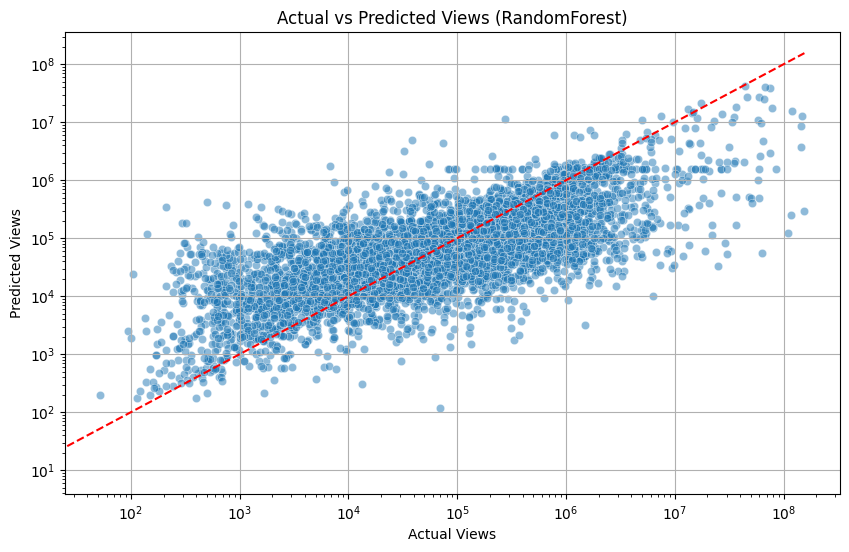

In [ ]:
# %% Models
models = {
    "LightGBM": LGBMRegressor(num_leaves=31, n_estimators=600, learning_rate=0.05, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(tree_method="hist", max_depth=8, learning_rate=0.08, n_estimators=500, random_state=42, n_jobs=-1),
    "Ridge": Ridge(alpha=1.0),
    "LinearSVR": LinearSVR(max_iter=20000, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=50, max_depth=None, random_state=42, n_jobs=-1)
}

results = []
for name, model in tqdm(models.items()):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    
    preds_val_log = model.predict(X_val)
    preds_val = np.expm1(np.clip(preds_val_log, -20, 20))
    y_val_actual = np.expm1(y_val)
    
    val_mse = mean_squared_error(y_val_actual, preds_val)
    val_mae = mean_absolute_error(y_val_actual, preds_val)
    val_r2 = r2_score(y_val_actual, preds_val)
    
    median_error = np.median(np.abs((preds_val - y_val_actual) / (y_val_actual + 1e-9)) * 100)
    
    results.append({
        'Model': name,
        'R2': val_r2,
        'MAE': val_mae,
        'MSE': val_mse,
        'Median % Error': median_error,
        'Train Time': train_time,
        'Model_Instance': model
    })

res_df_val = pd.DataFrame(results).sort_values('R2', ascending=False)
best_model_name = res_df_val.iloc[0]['Model']
best_model = res_df_val.iloc[0]['Model_Instance']

print("Validation Set Results:")
print(res_df_val[['Model','R2','MAE','MSE','Median % Error','Train Time']])

# Test Set Evaluation
preds_test_log = best_model.predict(X_test)
preds_test = np.expm1(np.clip(preds_test_log, -20, 20))
y_test_actual = np.expm1(y_test)

test_results = {
    'Model': best_model_name,
    'Test_R2': r2_score(y_test_actual, preds_test),
    'Test_MAE': mean_absolute_error(y_test_actual, preds_test),
    'Test_MSE': mean_squared_error(y_test_actual, preds_test),
    'Test_Median % Error': np.median(np.abs((preds_test - y_test_actual) / (y_test_actual + 1e-9)) * 100)
}

print("Test Set Results:")
print(pd.DataFrame([test_results]))

# Optional plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_actual, y=preds_test, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")
plt.title(f"Actual vs Predicted Views ({best_model_name})")
plt.grid(True)
plt.show()


In [ ]:
# %% === Hyperparameter Sweep for All Models === (Last Validation!)
from sklearn.model_selection import ParameterGrid

# Define small hyperparameter grids (10 combinations each) for quick testing
param_grids = {
    "RandomForest": {
        'n_estimators': [50, 100, 200, 400, 600],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.08, 0.1],
        'subsample': [0.8, 1.0]
    },
    "LightGBM": {
        'n_estimators': [100, 200, 400, 600],
        'num_leaves': [15, 31, 50],
        'learning_rate': [0.05, 0.08, 0.1],
        'subsample': [0.8, 1.0]
    },
    "Ridge": {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]},
    "LinearSVR": {'C': [0.1, 0.5, 1.0, 2.0, 5.0], 'epsilon': [0.0, 0.1]}
}

results = []

for model_name, grid in param_grids.items():
    print(f"\n=== Sweeping {model_name} ===")
    for params in tqdm(list(ParameterGrid(grid))[:10], desc=f"{model_name} hyperparams"):  # limit to 10
        if model_name == "RandomForest":
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        elif model_name == "XGBoost":
            model = XGBRegressor(tree_method="hist", random_state=42, n_jobs=-1, **params)
        elif model_name == "LightGBM":
            model = LGBMRegressor(random_state=42, n_jobs=-1, **params)
        elif model_name == "Ridge":
            model = Ridge(**params)
        elif model_name == "LinearSVR":
            model = LinearSVR(max_iter=20000, random_state=42, **params)
        else:
            continue
        
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - t0
        
        # Validation metrics
        preds_val_log = model.predict(X_val)
        preds_val = np.expm1(np.clip(preds_val_log, -20, 20))
        y_val_actual = np.expm1(y_val)
        
        val_mse = mean_squared_error(y_val_actual, preds_val)
        val_mae = mean_absolute_error(y_val_actual, preds_val)
        val_r2 = r2_score(y_val_actual, preds_val)
        median_error = np.median(np.abs((preds_val - y_val_actual) / (y_val_actual + 1e-9)) * 100)
        
        # Test metrics
        preds_test_log = model.predict(X_test)
        preds_test = np.expm1(np.clip(preds_test_log, -20, 20))
        y_test_actual = np.expm1(y_test)
        
        test_mse = mean_squared_error(y_test_actual, preds_test)
        test_mae = mean_absolute_error(y_test_actual, preds_test)
        test_r2 = r2_score(y_test_actual, preds_test)
        test_median_error = np.median(np.abs((preds_test - y_test_actual) / (y_test_actual + 1e-9)) * 100)
        
        results.append({
            'Model': model_name,
            **params,
            'Val_R2': round(val_r2, 4),
            'Val_MAE': round(val_mae, 2),
            'Val_MSE': round(val_mse, 2),
            'Val_Median % Error': round(median_error, 2),
            'Test_R2': round(test_r2, 4),
            'Test_MAE': round(test_mae, 2),
            'Test_MSE': round(test_mse, 2),
            'Test_Median % Error': round(test_median_error, 2),
            'Train_Time(s)': round(train_time, 2)
        })

# Convert to DataFrame and sort by validation R²
results_df = pd.DataFrame(results).sort_values('Val_R2', ascending=False).reset_index(drop=True)
display(results_df)



=== Sweeping RandomForest ===


RandomForest hyperparams: 100%|██████████| 10/10 [04:44<00:00, 28.42s/it]



=== Sweeping XGBoost ===


XGBoost hyperparams: 100%|██████████| 10/10 [04:31<00:00, 27.16s/it]



=== Sweeping LightGBM ===


...


=== Sweeping Ridge ===


Ridge hyperparams: 100%|██████████| 5/5 [00:00<00:00,  9.39it/s]



=== Sweeping LinearSVR ===


LinearSVR hyperparams: 100%|██████████| 10/10 [00:14<00:00,  1.45s/it]


,Model,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,Val_R2,Val_MAE,Val_MSE,Val_Median % Error,...,Test_MAE,Test_MSE,Test_Median % Error,Train_Time(s),learning_rate,subsample,num_leaves,alpha,C,epsilon
0,RandomForest,NaN,sqrt,1.0,2.0,50.0,0.1019,627780.80,2.221759e+13,74.96,...,780182.49,3.547147e+13,74.20,7.27,NaN,NaN,NaN,NaN,NaN,NaN
1,RandomForest,NaN,sqrt,1.0,2.0,200.0,0.0895,626911.02,2.252574e+13,75.37,...,779366.19,3.571787e+13,73.38,26.97,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomForest,NaN,sqrt,1.0,2.0,100.0,0.0876,628055.34,2.257063e+13,75.28,...,778884.90,3.551031e+13,73.73,13.31,NaN,NaN,NaN,NaN,NaN,NaN
3,RandomForest,NaN,sqrt,1.0,2.0,600.0,0.0823,626365.40,2.270280e+13,75.09,...,781598.54,3.582566e+13,73.66,96.52,NaN,NaN,NaN,NaN,NaN,NaN
4,RandomForest,NaN,sqrt,1.0,2.0,400.0,0.0815,627164.80,2.272174e+13,75.32,...,780344.47,3.582348e+13,73.42,56.44,NaN,NaN,NaN,NaN,NaN,NaN
5,RandomForest,NaN,sqrt,1.0,5.0,200.0,0.0683,627301.98,2.304801e+13,75.71,...,781664.78,3.602527e+13,74.58,12.42,NaN,NaN,NaN,NaN,NaN,NaN
6,RandomForest,NaN,sqrt,1.0,5.0,600.0,0.0672,627749.45,2.307731e+13,75.52,...,783596.64,3.606982e+13,74.04,34.50,NaN,NaN,NaN,NaN,NaN,NaN
7,RandomForest,NaN,sqrt,1.0,5.0,400.0,0.0671,627332.40,2.307813e+13,75.56,...,783152.97,3.607556e+13,74.26,23.58,NaN,NaN,NaN,NaN,NaN,NaN
8,RandomForest,NaN,sqrt,1.0,5.0,50.0,0.0656,628319.42,2.311541e+13,75.50,...,779474.76,3.575248e+13,74.97,3.27,NaN,NaN,NaN,NaN,NaN,NaN
9,RandomForest,NaN,sqrt,1.0,5.0,100.0,0.0629,628158.95,2.318249e+13,75.38,...,781533.13,3.591116e+13,75.01,6.55,NaN,NaN,NaN,NaN,NaN,NaN
